In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pycisTopic.cistopic_class import create_cistopic_object_from_fragments

/home/jovyan/pycisTopic/src/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
NOTEBOOK_DIR = os.getcwd()
REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))

SAMPLE = "8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller"
DEPENDENCIES = "/home/jovyan/work/PUMATAC_dependencies"

FRAGMENTS_PATH = os.path.join(
    NOTEBOOK_DIR, "notebooks_PUMATAC", "out", "data", "fragments",
    f"{SAMPLE}.fragments.tsv.gz",
)
REGIONS_BED = os.path.join(DEPENDENCIES, "regions", "V2.mm10-rDHS-Unfiltered.blacklisted.bed")
BLACKLIST_BED = os.path.join(DEPENDENCIES, "regions", "mm10-blacklist.v2.bed")

QC_OUT = os.path.join(REPO_ROOT, "results", "qc")
CISTOPIC_OUT = os.path.join(REPO_ROOT, "results", "cistopic")
os.makedirs(CISTOPIC_OUT, exist_ok=True)

BC_PASSING_FILTERS = os.path.join(QC_OUT, f"{SAMPLE}__bc_passing_filters_otsu.pkl")

for name, path in [
    ("fragments", FRAGMENTS_PATH),
    ("regions", REGIONS_BED),
    ("blacklist", BLACKLIST_BED),
    ("barcodes", BC_PASSING_FILTERS),
]:
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"{status:8s} {name:12s} {path}")

OK       fragments    /home/jovyan/work/repo/notebooks/notebooks_PUMATAC/out/data/fragments/8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller.fragments.tsv.gz
OK       regions      /home/jovyan/work/PUMATAC_dependencies/regions/V2.mm10-rDHS-Unfiltered.blacklisted.bed
OK       blacklist    /home/jovyan/work/PUMATAC_dependencies/regions/mm10-blacklist.v2.bed
OK       barcodes     /home/jovyan/work/repo/results/qc/8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller__bc_passing_filters_otsu.pkl


In [7]:
with open(BC_PASSING_FILTERS, "rb") as f:
    bc_passing_filters = pickle.load(f)

print(f"Barcodes passing QC filters: {len(bc_passing_filters)}")
print(f"Example: {bc_passing_filters[:3]}")

Barcodes passing QC filters: 6111
Example: ['CGCGTTGGACCTCAAA', 'TGGATTGACTTCGCCT', 'CTTCCTTTGTGCGTGC']


In [4]:
cistopic_obj = create_cistopic_object_from_fragments(
    path_to_fragments=FRAGMENTS_PATH,
    path_to_regions=REGIONS_BED,
    path_to_blacklist=BLACKLIST_BED,
    valid_bc=bc_passing_filters,
    n_cpu=8,
    project=SAMPLE,
)

print(cistopic_obj)

with open(os.path.join(CISTOPIC_OUT, f"{SAMPLE}__cto.pkl"), "wb") as f:
    pickle.dump(cistopic_obj, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"\nSaved to {CISTOPIC_OUT}")

2026-08-19 23:41:41,100 cisTopic     INFO     Reading data for 8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller
2026-08-19 23:52:11,815 cisTopic     INFO     valid_bc provided, selecting barcodes!
2026-08-19 23:52:34,799 cisTopic     INFO     Counting number of unique fragments (Unique_nr_frag)
2026-08-19 23:53:56,117 cisTopic     INFO     Counting fragments in regions


/opt/python4Jup/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-19 23:54:04,622	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-08-19 23:54:12,621	WARNING services.py:2248 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=10.24gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-08-19 23:54:20,233	INFO worker.py:2024 -- Started a local Ray instance.
(pid=117

2026-08-19 23:56:10,954 cisTopic     INFO     Creating fragment matrix


/home/jovyan/pycisTopic/src/pycisTopic/cistopic_class.py:886: PerformanceWarning: The following operation may generate 7405346466 cells in the resulting pandas object.
  .unstack(level="Name", fill_value=0)


2026-08-20 00:10:26,884 cisTopic     INFO     Converting fragment matrix to sparse matrix
2026-08-20 00:11:56,706 cisTopic     INFO     Removing blacklisted regions
2026-08-20 00:12:04,697 cisTopic     INFO     Creating CistopicObject
2026-08-20 00:12:12,603 cisTopic     INFO     Done!
CistopicObject from project 8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller with n_cells × n_regions = 6111 × 1211806

Saved to /home/jovyan/work/repo/results/cistopic


In [9]:
qc_stats = pd.read_parquet(
    os.path.join(QC_OUT, f"{SAMPLE}__fragments_stats_per_cb.parquet")
)
qc_stats = qc_stats.set_index("CB")
qc_stats.index = [f"{bc}___{SAMPLE}" for bc in qc_stats.index]

# Keep only the barcodes present in the cisTopic object, in the same order
qc_stats = qc_stats.reindex(cistopic_obj.cell_names)

print(f"Metadata rows aligned: {qc_stats.shape}")
print(f"Any missing after reindex: {qc_stats.isna().all(axis=1).sum()}")

cistopic_obj.add_cell_data(qc_stats)
print(cistopic_obj.cell_data.head(3))

with open(os.path.join(CISTOPIC_OUT, f"{SAMPLE}__cto.pkl"), "wb") as f:
    pickle.dump(cistopic_obj, f, protocol=pickle.HIGHEST_PROTOCOL)


Metadata rows aligned: (6111, 17)
Any missing after reindex: 0
Columns ['nucleosome_signal', 'unique_fragments_in_peaks_count', 'log10_unique_fragments_count', 'pdf_values_for_fraction_of_fragments_in_peaks', 'log10_unique_fragments_in_peaks_count', 'duplication_ratio', 'unique_fragments_count', 'log10_total_fragments_in_peaks_count', 'log10_total_fragments_count', 'total_fragments_in_peaks_count', 'duplication_count', 'pdf_values_for_tss_enrichment', 'fraction_of_fragments_in_peaks', 'tss_enrichment', 'pdf_values_for_duplication_ratio', 'total_fragments_count', 'barcode_rank'] will be overwritten
                                                   cisTopic_nr_acc  \
GCGCGAACTCTCATCC___8k_mouse_cortex_ATACv2_nextg...            9398   
GGGTAGTGAGATGGAC___8k_mouse_cortex_ATACv2_nextg...           22918   
AGAGAATTGAATCGCT___8k_mouse_cortex_ATACv2_nextg...           14540   

                                                   cisTopic_nr_frag  \
GCGCGAACTCTCATCC___8k_mouse_cortex_ATACv2_n

In [8]:
from pycisTopic.lda_models import run_cgs_models

LDA_OUT = os.path.join(REPO_ROOT, "results", "lda_models")
os.makedirs(LDA_OUT, exist_ok=True)

models = run_cgs_models(
    cistopic_obj,
    n_topics=[10, 20, 30, 40, 50],
    n_cpu=5,
    n_iter=150,
    random_state=555,
    alpha=50,
    alpha_by_topic=True,
    eta=0.1,
    eta_by_topic=False,
    save_path=LDA_OUT,
)

with open(os.path.join(LDA_OUT, f"{SAMPLE}__models.pkl"), "wb") as f:
    pickle.dump(models, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Done. Models saved to {LDA_OUT}")

2026-08-20 00:16:30,093	WARNING services.py:2248 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=10.24gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-08-20 00:16:40,974	INFO worker.py:2024 -- Started a local Ray instance.
(pid=1183817) /home/jovyan/pycisTopic/src/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
(pid=1183817)   from pkg_resources import DistributionNotFound, get_distribution


(run_cgs_model pid=1183817) 2026-08-20 00:16:50,021 cisTopic     INFO     Running model with 10 topics
(run_cgs_model pid=1183817) 2026-08-20 02:31:14,164 cisTopic     INFO     Model with 10 topics done!
(run_cgs_model pid=1183817) 2026-08-20 02:31:14,164 cisTopic     INFO     Saving model with 10 topics at /home/jovyan/work/repo/results/lda_models
(run_cgs_model pid=1183815) 2026-08-20 00:16:52,903 cisTopic     INFO     Running model with 50 topics [repeated 4x across cluster]
(run_cgs_model pid=1183816) 2026-08-20 03:31:19,604 cisTopic     INFO     Model with 20 topics done!
(run_cgs_model pid=1183816) 2026-08-20 03:31:19,604 cisTopic     INFO     Saving model with 20 topics at /home/jovyan/work/repo/results/lda_models
(run_cgs_model pid=1183814) 2026-08-20 04:26:34,084 cisTopic     INFO     Model with 30 topics done!
(run_cgs_model pid=1183814) 2026-08-20 04:26:34,084 cisTopic     INFO     Saving model with 30 topics at /home/jovyan/work/repo/results/lda_models
(run_cgs_model pid=11

(pid=1183815) /home/jovyan/pycisTopic/src/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81. [repeated 4x across cluster]
(pid=1183815)   from pkg_resources import DistributionNotFound, get_distribution [repeated 4x across cluster]


Done. Models saved to /home/jovyan/work/repo/results/lda_models


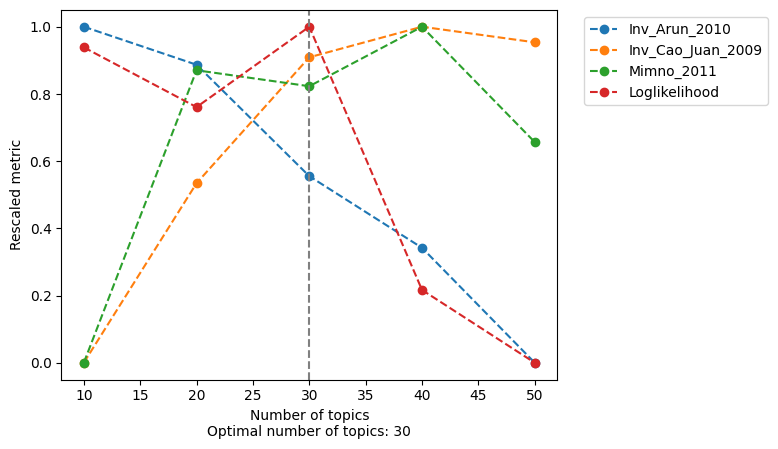

CistopicObject from project 8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller with n_cells × n_regions = 6111 × 1211806

Saved to /home/jovyan/work/repo/results/cistopic


In [10]:
from pycisTopic.lda_models import evaluate_models

model = evaluate_models(
    models,
    select_model=30,
    return_model=True,
)

cistopic_obj.add_LDA_model(model)

with open(os.path.join(CISTOPIC_OUT, f"{SAMPLE}__cto_with_model.pkl"), "wb") as f:
    pickle.dump(cistopic_obj, f, protocol=pickle.HIGHEST_PROTOCOL)

print(cistopic_obj)
print(f"\nSaved to {CISTOPIC_OUT}")

## Next step

Continue in `12_clustering.ipynb` with a **fresh kernel**.

Ray, used internally by the LDA step, and numba, used by UMAP's
nearest-neighbour routines, cannot both be initialised in the same kernel
session: running UMAP after the LDA raises a numba `TypingError` during
compilation. Restarting the kernel between the two steps avoids this.